# E-Commerce Sales Analytics

## Objective
Analyze e-commerce sales data to identify:
- Top performing products
- Profit drivers
- Regional performance
- Product segments
- Business recommendations

## Business Questions
1. Which products generate maximum profit?
2. Which category performs best?
3. Which region is most profitable?
4. What drives profit?
5. How can products be segmented?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [3]:
df.shape

(3500, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [5]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


## Data Cleaning

In [6]:
df = df.drop_duplicates()

In [7]:
df = df.drop_duplicates()

## Feature Engineering

Create useful analytics columns

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [11]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

Price per unit

In [12]:
df['Price_per_unit'] = df['Sales'] / df['Quantity']

Profit margin

In [13]:
df['Profit_margin'] = df['Profit'] / df['Sales']

Profit per unit

In [14]:
df['Profit_per_unit'] = df['Profit'] / df['Quantity']

## Exploratory Data Analysis
Monthly Sales Trend

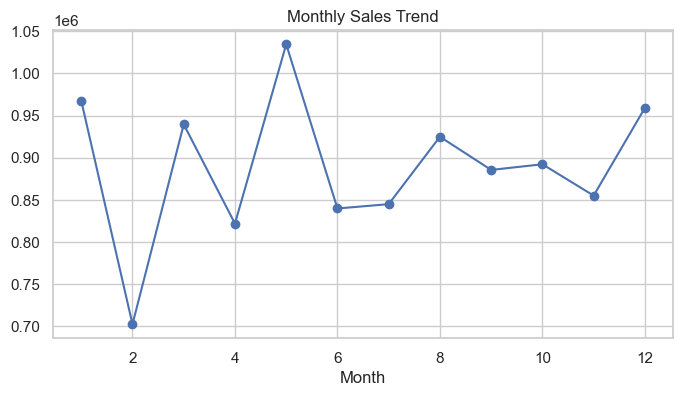

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.show()

Category Performance

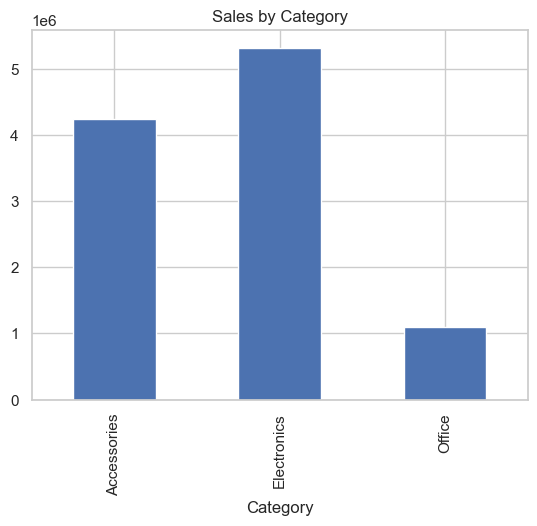

In [16]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

Region Performance

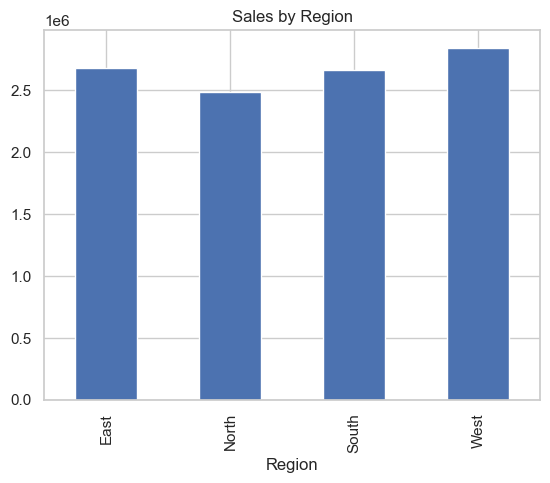

In [17]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

## Product Performance Analysis

Creating product dataframe

In [18]:
product_df = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Profit_margin':'mean'
}).reset_index()

Top products by profit

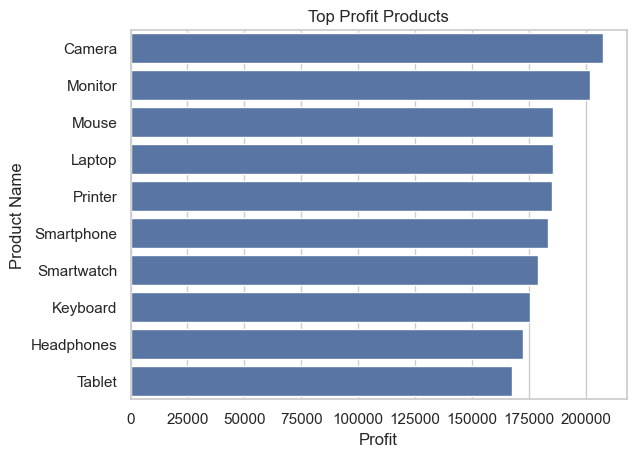

In [19]:
top_profit = product_df.sort_values('Profit', ascending=False).head(10)

sns.barplot(y='Product Name', x='Profit', data=top_profit)
plt.title("Top Profit Products")
plt.show()

## Profit Drivers Analysis

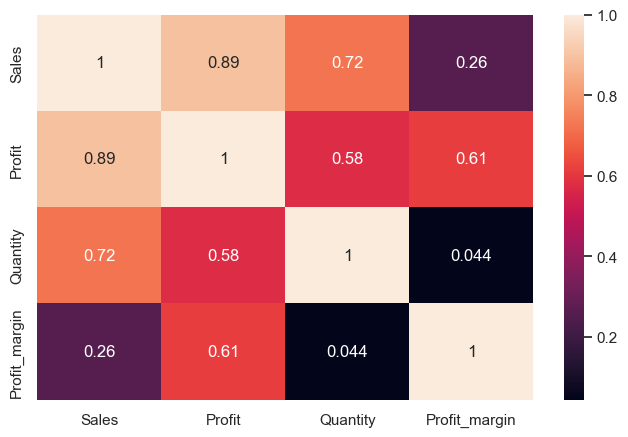

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    product_df[['Sales','Profit','Quantity','Profit_margin']].corr(),
    annot=True
)

plt.show()

Profit vs Quantity

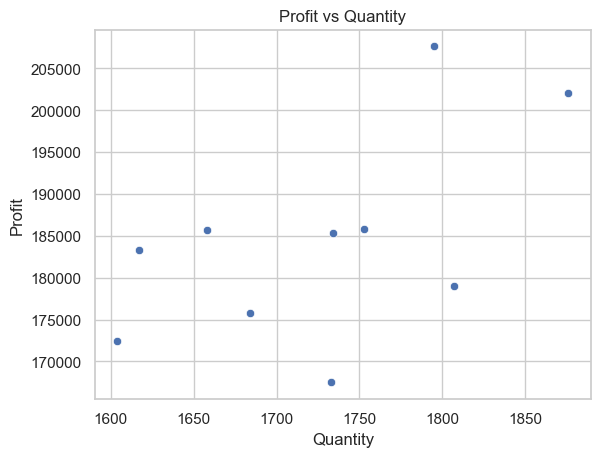

In [21]:
sns.scatterplot(
    x='Quantity',
    y='Profit',
    data=product_df
)

plt.title("Profit vs Quantity")
plt.show()

## Product Segmentation (KMeans)

In [22]:
X = product_df[['Sales','Profit','Quantity','Profit_margin']]

Scale data

In [23]:
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

Apply KMeans

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
product_df['Cluster'] = kmeans.fit_predict(scaled)

Cluster visualization

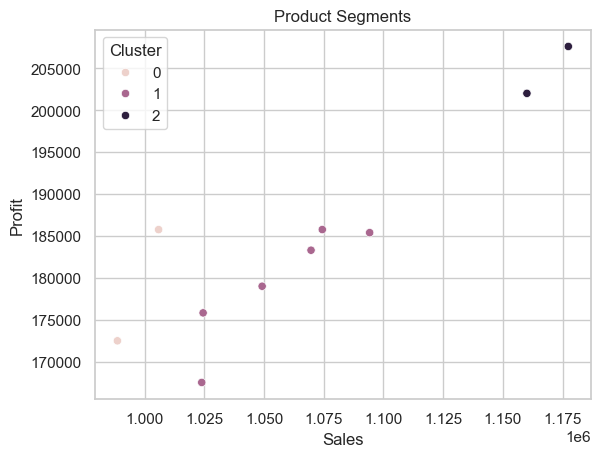

In [25]:
sns.scatterplot(
    x=product_df['Sales'],
    y=product_df['Profit'],
    hue=product_df['Cluster']
)

plt.title("Product Segments")
plt.show()

Cluster Summary

In [26]:
cluster_summary = product_df.groupby('Cluster').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean',
    'Profit_margin':'mean',
    'Product Name':'count'
})

cluster_summary

,Sales,Profit,Quantity,Profit_margin,Product Name
Cluster,,,,,
0,9.972555e+05,179117.505,1631.000000,0.175993,2
1,1.055990e+06,179461.840,1721.333333,0.172249,6
2,1.168714e+06,204829.580,1835.500000,0.175729,2


## Best Product

In [27]:
best_product = product_df.loc[
    product_df['Profit'].idxmax()
]

best_product

Product Name        Camera
Sales              1177381
Profit           207630.99
Quantity              1795
Profit_margin     0.178177
Cluster                  2
Name: 0, dtype: object

## Worst Product

In [28]:
worst_product = product_df.loc[
    product_df['Profit'].idxmin()
]

worst_product

Product Name        Tablet
Sales              1023928
Profit           167505.01
Quantity              1733
Profit_margin     0.169807
Cluster                  1
Name: 9, dtype: object

## Products in Each Cluster

In [29]:
for i in range(3):
    print(f"\nCluster {i}")
    print(
        product_df[product_df['Cluster']==i]['Product Name'].values
    )


Cluster 0
['Headphones' 'Laptop']

Cluster 1
['Keyboard' 'Mouse' 'Printer' 'Smartphone' 'Smartwatch' 'Tablet']

Cluster 2
['Camera' 'Monitor']


Cluster 0 — High Profit Products
- increase marketing
- maintain pricing
- increase inventory

Cluster 1 — Moderate Products
- optimize pricing
- bundle offers

Cluster 2 — Low Performance
- discount clearance
- reduce inventory

KPI Metrics

In [30]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

best_product = product_df.loc[product_df['Profit'].idxmax()]['Product Name']
worst_product = product_df.loc[product_df['Profit'].idxmin()]['Product Name']

total_sales, total_profit, best_product, worst_product

(np.int64(10667881), np.float64(1844665.21), 'Camera', 'Tablet')

Save Processed Data

In [31]:
df.to_csv("processed_data.csv", index=False)
product_df.to_csv("product_data.csv", index=False)